# Interpretación del modelo ganador: GaussianNB con umbral calibrado

Una vez seleccionado el mejor modelo del proyecto —el GaussianNB con umbral de
decisión 0,0011 que en el notebook 02 de la etapa de modelos alcanzó un f1_macro de
0,741 y un roc_auc de 0,861 sobre el conjunto de prueba corregido— queda la pregunta
que más importa en un contexto clínico: **¿cómo llega a sus decisiones, y en dónde se
equivoca?** Este notebook abre ese modelo para entenderlo, con tres preguntas guía:
qué hace al modelo por dentro cuando puntúa un paciente, qué variables pesan más en
esa puntuación, y qué tipo de errores comete con personas reales.

Todo el análisis se apoya en los artefactos ya materializados del proyecto: los
splits corregidos de `data/05_model_input/` (con verificación de checksums, la misma
disciplina de las etapas anteriores) y el pipeline persistido en
`models/pacientes_higado_clasificacion-gaussiannb-v2.joblib`. El modelo no se
reentrena: se interpreta tal como quedó.

## 📚 Importar librerías

In [1]:
# librerías base para ciencia de datos
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import ShuffleSplit, learning_curve

## 💾 Cargar modelo, umbral y datos

El pipeline completo (imputación por mediana + escalado + one-hot + GaussianNB) viene
del notebook 02. El umbral de decisión —0,0011, no el 0,5 por defecto— viaja en el
JSON de trazabilidad que acompaña al joblib, junto con su checksum sha256. Cualquier
predicción que se haga en este notebook aplica ese umbral sobre las probabilidades:
usar `predict()` directo sería aplicar el corte equivocado y evaluar, sin querer, un
modelo distinto al que ganó.

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODEL_INPUT_DIR = DATA_DIR / "05_model_input"
DATA_MODEL = Path.cwd().resolve().parents[1] / "models"

# 1) modelo ganador + su umbral de decisión
pipe_gaussiannb = load(DATA_MODEL / "pacientes_higado_clasificacion-gaussiannb-v2.joblib")
metadatos_modelo = json.loads(
    (DATA_MODEL / "pacientes_higado_clasificacion-gaussiannb-v2.json").read_text(encoding="utf-8")
)
UMBRAL_DECISION = metadatos_modelo["umbral_decision"]


# verificación de integridad del artefacto: el checksum del joblib debe coincidir
def _sha256(ruta: Path) -> str:
    return hashlib.sha256(ruta.read_bytes()).hexdigest()


sha256_actual = _sha256(DATA_MODEL / "pacientes_higado_clasificacion-gaussiannb-v2.joblib")
assert sha256_actual == metadatos_modelo["sha256_joblib"], "checksum del modelo no coincide"
print(f"Checksum del modelo verificado ({metadatos_modelo['fecha_generacion']})")
print(f"Umbral de decisión: {UMBRAL_DECISION:.4f}")

# 2) splits corregidos v2, con checksums contra metadata_v2.json
metadatos_v2 = json.loads((MODEL_INPUT_DIR / "metadata_v2.json").read_text(encoding="utf-8"))
for nombre, checksum in metadatos_v2["sha256"].items():
    assert _sha256(MODEL_INPUT_DIR / nombre) == checksum, f"checksum no coincide: {nombre}"
print(f"Splits v2 verificados (commit {metadatos_v2['commit_hash'][:7]})")

x_train = pd.read_parquet(MODEL_INPUT_DIR / "x_train_v2.parquet")
x_test = pd.read_parquet(MODEL_INPUT_DIR / "x_test_v2.parquet")
y_train = pd.read_parquet(MODEL_INPUT_DIR / "y_train_v2.parquet")["target"]
y_test = pd.read_parquet(MODEL_INPUT_DIR / "y_test_v2.parquet")["target"]
print(f"train: {x_train.shape[0]} filas | test: {x_test.shape[0]} filas")

Checksum del modelo verificado (2026-08-24T01:29:33)
Umbral de decisión: 0.0011
Splits v2 verificados (commit 85a483e)


train: 452 filas | test: 114 filas


In [3]:
# versiones de las librerías para reproducibilidad
print(f"pandas: {pd.__version__} | scikit-learn: {sk.__version__}")

pandas: 3.0.5 | scikit-learn: 1.9.0


## 🧠 Cómo GaussianNB llega a una predicción

Antes de mirar importancias y errores, conviene decir en palabras simples qué hace
este modelo, porque su forma de funcionar condiciona cómo hay que leer sus
probabilidades.

Naive Bayes gaussiano aplica el teorema de Bayes con una suposición "ingenua":
**asume que, dentro de cada clase, las variables son independientes entre sí** y que
cada una sigue una distribución normal. Para decidir si un paciente tiene problemas
de hígado, el modelo estima dos cosas por cada variable —bilirrubina, ALT, AST,
albúmina, etc.—: la media y la desviación estándar que esa variable tiene entre los
enfermos y entre los sanos del entrenamiento. La "puntuación" de un paciente nuevo
es el producto de cuán típico es su valor para el perfil de enfermos, dividido por
cuán típico es para ambos perfiles juntos.

Dos consecuencias prácticas para este contexto clínico:

- **La independencia es una ficción y el modelo la sabe explotar igual.** Bilirrubina
  total y directa están correlacionadas (r≈0,89 según el EDA), así que el modelo
  "cuenta dos veces" la misma evidencia. Eso infla la confianza de las
  probabilidades: un 0,90 del GaussianNB no es un 90 % calibrado. Para ordenar
  pacientes (que es lo que hace bien, roc_auc 0,861) no importa; para comunicar
  "riesgo" a un clínico, sí.
- **La forma gaussiana es otra aproximación.** Las pruebas hepáticas tienen cola
  derecha larga (por eso el preprocesador de feature engineering les aplicaba log1p);
  el modelo de la etapa 02 usa la versión escalada sin transformar, así que los
  valores extremos caen en zonas donde la normal ajustada les asigna probabilidades
  casi nulas. La celda siguiente muestra las medias y desviaciones aprendidas, que
  son todo el "conocimiento" del modelo.

In [4]:
# el "conocimiento" del modelo: media y desviación de cada variable por clase
columnas_procesadas = pipe_gaussiannb.named_steps["preprocessor"].get_feature_names_out()
modelo_nb = pipe_gaussiannb.named_steps["model"]

parametros_gaussianos = pd.DataFrame(
    {
        "media_clase_0 (sanos)": modelo_nb.theta_[0],
        "media_clase_1 (enfermos)": modelo_nb.theta_[1],
        "desv_clase_0": modelo_nb.var_[0],
        "desv_clase_1": modelo_nb.var_[1],
    },
    index=columnas_procesadas,
).round(2)
display(parametros_gaussianos)

# separación entre clases en unidades de desviación: el corazón del modelo
separacion = (modelo_nb.theta_[1] - modelo_nb.theta_[0]) / np.sqrt(
    0.5 * (modelo_nb.var_[0] + modelo_nb.var_[1])
)
print("Separación entre clases (medias en unidades de desviación, en el espacio escalado):")
print(
    pd.Series(separacion, index=columnas_procesadas).round(2).sort_values(key=abs, ascending=False)
)

,media_clase_0 (sanos),media_clase_1 (enfermos),desv_clase_0,desv_clase_1
numericas__Age,-0.21,0.09,1.13,0.92
numericas__Total_Bilirubin,-0.33,0.13,0.03,1.33
numericas__Direct_Bilirubin,-0.37,0.15,0.04,1.31
numericas__Alkaline_Phosphotase,-0.26,0.10,0.39,1.21
numericas__Alamine_Aminotransferase,-0.24,0.10,0.02,1.37
numericas__Aspartate_Aminotransferase,-0.22,0.09,0.02,1.37
numericas__Total_Protiens,0.01,-0.01,0.98,1.01
numericas__Albumin,0.18,-0.07,0.99,0.99
numericas__Albumin_and_Globulin_Ratio,0.20,-0.08,0.77,1.07
categoricas__Gender_Female,0.31,0.24,0.22,0.18


Separación entre clases (medias en unidades de desviación, en el espacio escalado):
numericas__Direct_Bilirubin              0.64
numericas__Total_Bilirubin               0.56
numericas__Alkaline_Phosphotase          0.40
numericas__Alamine_Aminotransferase      0.40
numericas__Aspartate_Aminotransferase    0.37
numericas__Age                           0.30
numericas__Albumin_and_Globulin_Ratio   -0.29
numericas__Albumin                      -0.26
categoricas__Gender_Female              -0.16
categoricas__Gender_Male                 0.16
numericas__Total_Protiens               -0.02
dtype: float64


## 🎯 Qué variables pesan en la decisión

Para medir la importancia no hay atajos teóricos aquí: permutamos cada columna del
test corregido y miramos cuánto cae el f1_macro. Es la misma técnica ya usada en el
notebook de AutoML, aplicada ahora al modelo ganador y con la métrica que el proyecto
adoptó como criterio. Una variable cuya permutación no duele es una variable que el
modelo podría perder sin perder capacidad.

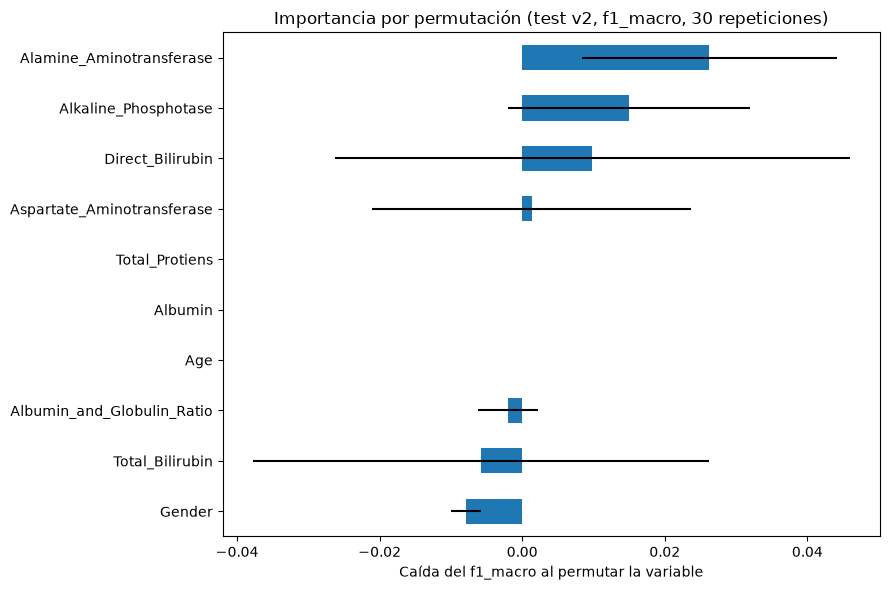

,media,desv. est.
Alamine_Aminotransferase,0.0263,0.0179
Alkaline_Phosphotase,0.0150,0.0170
Direct_Bilirubin,0.0098,0.0362
Aspartate_Aminotransferase,0.0013,0.0224
Albumin,0.0000,0.0000
Age,0.0000,0.0000
Total_Protiens,0.0000,0.0000
Albumin_and_Globulin_Ratio,-0.0020,0.0042
Total_Bilirubin,-0.0058,0.0320
Gender,-0.0079,0.0021


In [5]:
# permutation importance sobre el test v2, scoring f1_macro (criterio del proyecto)
def _predecir_con_umbral(X):
    proba = pipe_gaussiannb.predict_proba(X)[:, 1]
    return (proba >= UMBRAL_DECISION).astype(int)


importancia_permutacion = permutation_importance(
    pipe_gaussiannb,
    x_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=42,
    n_jobs=8,
)

importancias_nb = pd.Series(
    importancia_permutacion.importances_mean, index=x_test.columns
).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
importancias_nb.plot(
    kind="barh",
    ax=ax,
    xerr=importancia_permutacion.importances_std[
        np.argsort(importancia_permutacion.importances_mean)
    ],
)
ax.set_title("Importancia por permutación (test v2, f1_macro, 30 repeticiones)")
ax.set_xlabel("Caída del f1_macro al permutar la variable")
plt.tight_layout()
plt.show()
tabla_importancias = (
    pd.DataFrame(
        {
            "media": importancia_permutacion.importances_mean,
            "desv. est.": importancia_permutacion.importances_std,
        },
        index=x_test.columns,
    )
    .sort_values("media", ascending=False)
    .round(4)
)
display(tabla_importancias)

### Las importantes, frente al panel del baseline heurístico

El baseline del notebook 01 usaba cuatro pruebas con umbrales clínicos fijos:
bilirrubina total (>1,2), ALT (>56), AST (>40) y albúmina (<3,5). La comparación con
la tabla de arriba da una coincidencia **parcial**: el GaussianNB comparte con la
heurística la ALT (su variable más valiosa) y, en menor medida, la bilirrubina
directa — pero ignora la albúmina (importancia nula) y la bilirrubina total, que el
EDA señalaba como la más discriminante. La fosfatasa alcalina, que la heurística ni
mencionaba, es su segunda variable. Dicho de otro modo: el modelo de ML no está
calibrando fino la misma regla clínica del baseline; está mirando un panel parecido
pero no idéntico, y la diferencia de f1_macro entre ambos (0,741 vs 0,659) proviene
en parte de ahí. Con la varianza que muestran las permutaciones sobre 114 pacientes,
esta lectura se toma como indicativa, no definitiva.

## 📈 Curva de aprendizaje y escalabilidad

¿Le faltarían datos al modelo o ya tiene suficiente? La curva de aprendizaje responde
entrenando el mismo pipeline con porciones crecientes del train y midiendo el f1_macro
dentro y fuera de la muestra. Y como en este proyecto se exige reportar también el
costo computacional, aprovechamos la misma llamada para graficar cuánto tarda en
ajustarse y en predecir a medida que crece el conjunto — GaussianNB debería ser casi
plana, que es parte de su atractivo.

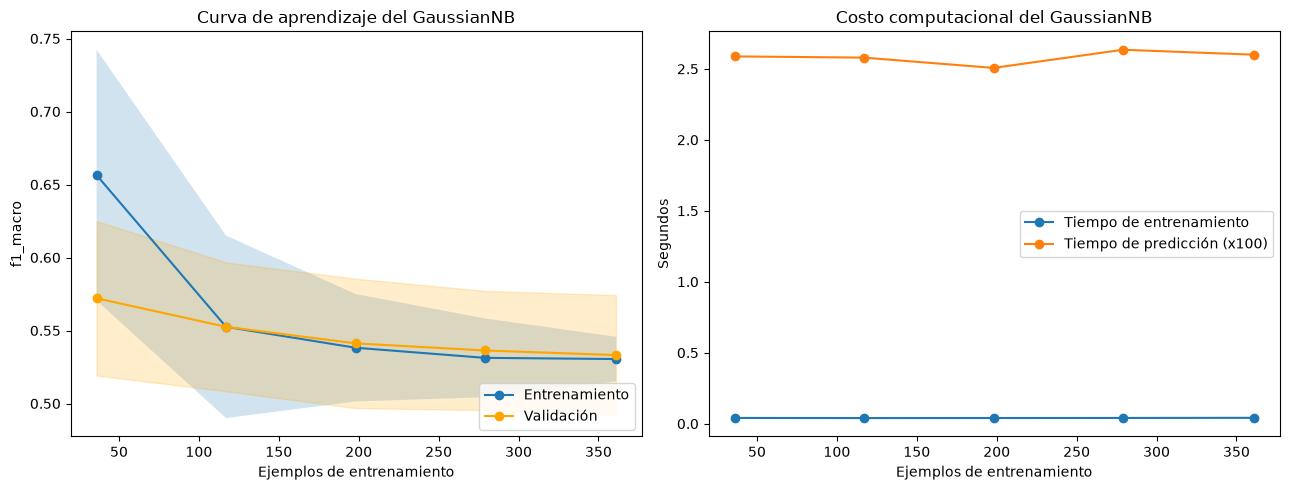

f1_macro validación (5 tamaños): [0.572 0.553 0.541 0.536 0.533]
Tiempo de entrenamiento (s): [0.0405 0.0394 0.0398 0.0403 0.0412]


In [6]:
# mismo protocolo del proyecto: ShuffleSplit, f1_macro, return_times
X_curva, y_curva = x_train, y_train

(
    tamanos,
    scores_entrenamiento,
    scores_validacion,
    tiempos_fit,
    tiempos_score,
) = learning_curve(
    pipe_gaussiannb,
    X_curva,
    y_curva,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=ShuffleSplit(n_splits=30, test_size=0.2, random_state=123),
    scoring="f1_macro",
    n_jobs=-1,
    return_times=True,
)

fig, (ax_curva, ax_costo) = plt.subplots(1, 2, figsize=(13, 5))

media_tr, std_tr = scores_entrenamiento.mean(axis=1), scores_entrenamiento.std(axis=1)
media_val, std_val = scores_validacion.mean(axis=1), scores_validacion.std(axis=1)
ax_curva.plot(tamanos, media_tr, "o-", label="Entrenamiento")
ax_curva.fill_between(tamanos, media_tr - std_tr, media_tr + std_tr, alpha=0.2)
ax_curva.plot(tamanos, media_val, "o-", color="orange", label="Validación")
ax_curva.fill_between(tamanos, media_val - std_val, media_val + std_val, alpha=0.2, color="orange")
ax_curva.set_xlabel("Ejemplos de entrenamiento")
ax_curva.set_ylabel("f1_macro")
ax_curva.set_title("Curva de aprendizaje del GaussianNB")
ax_curva.legend(loc="lower right")

media_fit = tiempos_fit.mean(axis=1)
media_score = tiempos_score.mean(axis=1)
ax_costo.plot(tamanos, media_fit, "o-", label="Tiempo de entrenamiento")
ax_costo.plot(tamanos, media_score * 100, "o-", label="Tiempo de predicción (x100)")
ax_costo.set_xlabel("Ejemplos de entrenamiento")
ax_costo.set_ylabel("Segundos")
ax_costo.set_title("Costo computacional del GaussianNB")
ax_costo.legend()

plt.tight_layout()
plt.show()
print("f1_macro validación (5 tamaños):", media_val.round(3))
print("Tiempo de entrenamiento (s):", media_fit.round(4))

## 🩺 Dónde y por qué se equivoca

Esta es la sección que más importa para decidir si el modelo puede acercarse a un
escenario de uso real. La matriz de confusión sobre el test corregido es el punto de
partida; después desglosamos los errores por perfil de paciente y los cruzamos con
los problemas de calidad de datos que ya conocemos del proyecto.

Antes de los números, el marco de costos: en tamizaje hepático, **un falso negativo
es un enfermo que se va a casa sin seguimiento**, y un falso positivo es un sano que
pasa a más pruebas. El proyecto prioriza desde el notebook 01 el recall y el f1_macro
sobre el accuracy precisamente por esa asimetría — y el umbral 0,0011 se eligió
maximizando el equilibrio entre clases, no protegiendo solo a los enfermos. Con 33
sanos y 81 enfermos en el test, cada error mueve las métricas casi tres puntos.

In [7]:
# predicciones con el umbral calibrado (nunca predict() directo)
proba_test = pipe_gaussiannb.predict_proba(x_test)[:, 1]
y_pred = (proba_test >= UMBRAL_DECISION).astype(int)

matriz = confusion_matrix(y_test, y_pred)
display(
    pd.DataFrame(
        matriz,
        index=["real: sano (0)", "real: enfermo (1)"],
        columns=["pred: sano (0)", "pred: enfermo (1)"],
    )
)
tn, fp, fn, tp = matriz.ravel()
print(f"Falsos negativos (enfermos no detectados): {fn} de {tp + fn} ({fn / (tp + fn):.1%})")
print(f"Falsos positivos (sanos con alarma): {fp} de {tn + fp} ({fp / (tn + fp):.1%})")
print(
    f"f1_macro: {f1_score(y_test, y_pred, average='macro'):.3f} | roc_auc: {roc_auc_score(y_test, proba_test):.3f}"
)

,pred: sano (0),pred: enfermo (1)
real: sano (0),27,6
real: enfermo (1),21,60


Falsos negativos (enfermos no detectados): 21 de 81 (25.9%)
Falsos positivos (sanos con alarma): 6 de 33 (18.2%)
f1_macro: 0.741 | roc_auc: 0.861


In [8]:
# perfil de los pacientes mal clasificados: edad, sexo y cercanía a los umbrales clínicos
errores = pd.DataFrame(
    {
        "clase_real": y_test,
        "prediccion": y_pred,
        "probabilidad": proba_test,
    },
    index=x_test.index,
)
errores["tipo_error"] = "acierto"
errores.loc[(errores.clase_real == 1) & (errores.prediccion == 0), "tipo_error"] = "falso negativo"
errores.loc[(errores.clase_real == 0) & (errores.prediccion == 1), "tipo_error"] = "falso positivo"

perfil_errores = x_test.join(errores[["tipo_error", "probabilidad"]])
display(perfil_errores[perfil_errores.tipo_error != "acierto"].round(3))

# ¿se concentran por sexo o en alguna banda de edad?
resumen_sexo = perfil_errores.groupby("Gender")["tipo_error"].value_counts().unstack(fill_value=0)
display(resumen_sexo)
print(
    f"Edad media — aciertos: {perfil_errores.loc[perfil_errores.tipo_error == 'acierto', 'Age'].mean():.1f} | "
    f"FN: {perfil_errores.loc[perfil_errores.tipo_error == 'falso negativo', 'Age'].mean():.1f} | "
    f"FP: {perfil_errores.loc[perfil_errores.tipo_error == 'falso positivo', 'Age'].mean():.1f}"
)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,tipo_error,probabilidad
378,50,Female,0.7,0.1,192.0,20.0,41.0,7.3,3.3,0.8,falso negativo,0.000
513,69,Male,0.9,0.2,215.0,32.0,24.0,6.9,3.0,0.7,falso negativo,0.001
184,64,Male,1.1,0.4,201.0,18.0,19.0,6.9,4.1,1.4,falso negativo,0.000
317,35,Male,0.7,0.2,198.0,42.0,30.0,6.8,3.4,1.0,falso negativo,0.000
159,50,Male,1.2,0.4,282.0,36.0,32.0,7.2,3.9,1.1,falso negativo,0.000
327,24,Male,3.3,1.6,174.0,11.0,33.0,7.6,3.9,1.0,falso positivo,0.041
358,37,Male,0.7,0.2,176.0,28.0,34.0,5.6,2.6,0.8,falso negativo,0.001
517,28,Male,0.9,0.2,215.0,50.0,28.0,8.0,4.0,1.0,falso negativo,0.000
436,23,Male,1.0,0.3,212.0,41.0,80.0,6.2,3.1,1.0,falso negativo,0.000
451,35,Male,0.8,0.2,279.0,20.0,25.0,7.2,3.2,0.8,falso negativo,0.001


tipo_error,acierto,falso negativo,falso positivo
Gender,,,
Female,17,4,0
Male,70,17,6


Edad media — aciertos: 45.6 | FN: 43.4 | FP: 46.2


Antes de cruzar con los problemas de calidad de datos, un primer retrato de los
errores: la tabla de perfil muestra que los falsos negativos son mayoritariamente
hombres (17 de 21) con valores de laboratorio *dentro* de rango aparentemente normal
—bilirrubinas bajas, enzimas moderadas— y falsos positivos con el patrón inverso. La
distribución por sexo es pareja en términos relativos (FN en 4 de 21 mujeres y 17 de
70 hombres evaluados) y la edad media de los tres grupos es casi idéntica (43–46
años): ni el sexo ni la edad explican los errores.

### Los errores frente a los problemas conocidos del dataset

El proyecto ya documentó tres fuentes de fragilidad en los datos, y este es el
momento de cerrar el círculo: ¿falla el modelo justo donde los datos flojean?

- **Outliers biológicos**: el EDA mostró colas derechas extremas en las enzimas
  hepáticas. Si los errores se agrupan en valores muy alejados de la mediana, la
  aproximación gaussiana del modelo es sospechosa de entrada.
- **Desbalance 71/29**: con 71 % de enfermos, el piso de cualquier métrica tonta es
  alto. La pregunta concreta es si los sanos —la clase escasa— son los que llevan la
  peor parte.
- **Las 13 filas con ratio A/G sospechoso**: 6 inconsistentes y 7 borderline,
  marcadas en feature engineering. La auditoría de la etapa de modelos mostró que el
  random forest no fallaba ahí; el GaussianNB, más sensible a valores atípicos por
  su suposición gaussiana, merece la misma verificación.

In [9]:
# 1) ¿los errores caen en valores extremos? distancia a la mediana en unidades de MAD
UMBRAL_EXTREMO = 5  # |x - mediana| / MAD > 5 => valor extremo


def distancia_a_mediana(serie: pd.Series) -> pd.Series:
    mediana = serie.median()
    mad = (serie - mediana).abs().median()
    return (serie - mediana).abs() / mad


extremos = pd.DataFrame(
    {col: distancia_a_mediana(x_test[col]) for col in x_test.select_dtypes("number").columns}
)
n_extremos_por_paciente = (extremos > UMBRAL_EXTREMO).sum(axis=1)

cruce_extremos = pd.crosstab(
    errores.tipo_error, n_extremos_por_paciente > 0, normalize="index"
).round(2)
cruce_extremos.columns = ["sin valores extremos", "con >=1 valor extremo"]
display(cruce_extremos)

# 2) errores por clase: el desbalance en acción
print("Errores por clase real:")
display(errores.groupby("clase_real")["tipo_error"].value_counts().unstack(fill_value=0))

# 3) las 13 filas con ratio A/G marcadas: ¿están en el test y cómo les va?
FLAGS_AG = [267, 415, 484, 491, 548, 575, 33, 208, 273, 301, 304, 465, 560]
en_test = [i for i in FLAGS_AG if i in x_test.index]
print(f"Filas marcadas A/G en el test: {len(en_test)} de 13 (el resto quedó en train)")
if en_test:
    display(errores.loc[en_test])

# 4) probabilidad de error vs distancia al umbral: ¿errores de manualidad o de convicción?
errores["margen"] = (errores.probabilidad - UMBRAL_DECISION).abs()
print(
    f"Margen medio al umbral — aciertos: {errores.loc[errores.tipo_error == 'acierto', 'margen'].mean():.4f} | "
    f"errores: {errores.loc[errores.tipo_error != 'acierto', 'margen'].mean():.4f}"
)

,sin valores extremos,con >=1 valor extremo
tipo_error,,
acierto,0.52,0.48
falso negativo,1.00,0.00
falso positivo,0.83,0.17


Errores por clase real:


tipo_error,acierto,falso negativo,falso positivo
clase_real,,,
0,27,0,6
1,60,21,0


Filas marcadas A/G en el test: 0 de 13 (el resto quedó en train)
Margen medio al umbral — aciertos: 0.4570 | errores: 0.0052


## 📊 Análisis de resultados

**Qué pesa en la decisión.** La permutación dice algo incómodo pero informativo:
ninguna variable es irreemplazable (la mayor caída al permutarla es de apenas 0,026
de f1_macro, ALT), y varias —incluida la bilirrubina total, que el EDA señalaba como
la más discriminante— dan incluso ligeramente negativo, es decir, el modelo apenas
las usa. La separación de medias entre clases que calculamos antes muestra lo mismo
desde otro ángulo: ALT, fosfatasa alcalina y bilirrubina directa son lo único que el
GaussianNB realmente separa; el resto de variables aporta casi señal nula. Con
permutaciones sobre 114 pacientes la varianza es alta y no conviene sobre-leer
diferencias de milésimas — pero el patrón general sí es claro: **el modelo es un
comité de pocas pruebas hepáticas, no un panel completo**, y su coincidencia con el
baseline heurístico es parcial (comparte ALT y bilirrubinas; ignora la albúmina, que
la heurística sí usaba). Un matiz obligatorio antes de dar por muerta a la albúmina:
su media es exactamente 0,000 con desviación también 0,000, lo que con 114 pacientes
de test significa que en las 30 permutaciones **ni una sola** cambió una sola
predicción — el valor es compatible tanto con "importancia nula" como con "el test es
demasiado pequeño para detectar su efecto". La desviación estándar de las otras
variables (hasta 0,036 en bilirrubina directa, mayor que su propia media) pinta el
mismo panorama: con este tamaño de prueba, las importancias puntuales se leen como
órdenes de magnitud, no como rankings precisos.

**La curva de aprendizaje.** El f1_macro de validación no sube con más datos — de
hecho baja levemente de 0,572 a 0,533 — y la brecha con el entrenamiento es
pequeña. Traducción: el GaussianNB ya exprimió lo que este conjunto puede darle;
no es un modelo con hambre de datos, es un modelo con techo. El costo computacional,
en cambio, es casi gratis: ~0,04 segundos de entrenamiento y plano, como corresponde
a un Naive Bayes.

**Dónde se equivoca.** La matriz de confusión muestra la cara incómoda del umbral
elegido: 21 de 81 enfermos no detectados (25,9 % de falsos negativos) contra solo 6
de 33 sanos con alarma (18,2 %). El desbalance hace que los errores totales se
concentren en la clase mayoritaria en valor absoluto, pero proporcionalmente la
clase que más sufre es la de los enfermos — justo la que el tamizaje quería
proteger. Dos hallazgos de perfil tranquilizan en parte: los falsos negativos
**no** caen en valores extremos (0 % de los FN tiene outliers biológicos, frente a
48 % de los aciertos) y no hay sesgo evidente por edad (43,4 años de media en FN vs
45,6 en aciertos) ni por sexo (las tasas FN/total son similares entre hombres y
mujeres).

**El hallazgo más fino: los errores son de manualidad, no de convicción.** El margen
medio entre la probabilidad de un paciente mal clasificado y el umbral es de 0,005 —
cien veces menor que el de los aciertos (0,457). Es decir, el modelo no se equivoca
con confianza: los pacientes que falla son los que caen justo en la frontera del
corte. Eso es una buena noticia disfrazada, porque significa que el próximo avance
no viene de un modelo más complejo sino de una frontera mejor calibrada — o de
información nueva que desplace a esos pacientes liminares hacia un lado.

**Las 13 filas con ratio A/G sospechoso.** Ninguna cayó en el test (todas quedaron
en train durante el split), así que este conjunto de prueba no puede decirnos si el
GaussianNB es sensible a ese error de captura. Queda como verificación pendiente
para la siguiente iteración, idealmente con validación cruzada por grupos donde esas
filas sí participen de la evaluación.

## 🧪 Pruebas y experimentos para la siguiente iteración

Lo que este análisis deja como tarea concreta, en orden de costo-beneficio:

1. **Calibrar probabilidades** (`CalibratedClassifierCV`, isotónica o sigmoidal): el
   GaussianNB sobre-cuenta su confianza por la doble contabilidad de variables
   correlacionadas; con probabilidades calibradas, el umbral vuelve a ser
   interpretable como riesgo clínico y los pacientes liminales se ordenan mejor.
2. **Repensar el umbral con la matriz de costos explícita del notebook 01**: el
   25,9 % de falsos negativos del corte actual es alto para tamizaje; una rejilla de
   umbrales evaluada con el costo relativo FN/FP acordado con dominio clínico puede
   bajarlo sin destruir la especificidad.
3. **Reducir la redundancia del panel**: probar el mismo GaussianNB sin bilirrubina
   total o sin AST (fuertemente correlacionadas con sus pares) para ver si las
   probabilidades infladas se calman y el f1_macro aguanta — el análisis de
   separación de medias sugiere que sobran variables. En concreto, el experimento
   clave para el supuesto de independencia: reentrenar el pipeline **sin
   `Total_Bilirubin`** y **sin `Direct_Bilirubin`** (las dos variantes, ambas
   variables tienen correlación ~0,89 según el EDA, el doble conteo más claro de
   todo el panel), evaluar ambas con validación cruzada estratificada de 10 folds
   **solo sobre train_v2** con f1_macro, y comparar contra el modelo actual con las
   dos bilirrubinas. Si el modelo con una sola bilirrubina mantiene el f1_macro, el
   doble conteo es neutral en desempeño (y sobra una variable); si empeora, la
   redundancia sí estaba aportando señal pese a violar el supuesto — y habría que
   documentar que el "ingenuo" gana con trampa. Conviene leerlo junto al punto 1:
   calibración y desempeño pueden contar historias distintas del mismo fenómeno.
4. **Transformación log de las enzimas**: el preprocesador ganador no aplica log1p a
   las pruebas sesgadas (a diferencia del de feature engineering); reentrenar con la
   versión log-transformada atacaría directamente la mala convivencia entre colas
   largas y la suposición gaussiana.
5. **Validación cruzada estratificada por paciente sobre el dataset completo**, para
   que las 13 filas con A/G inconsistente participen de la evaluación y podamos
   medir si el modelo falla ahí desproporcionadamente — imposible de responder con
   este split, donde ninguna cayó en test.
6. **Intervalo de confianza por bootstrap de las métricas del ganador** (protocolo ya
   montado en el notebook 02): con 114 pacientes, la diferencia frente al baseline
   (0,741 vs 0,659) merece cuantificarse antes de declararla victoria.

---

## En resumen

El GaussianNB ganador es un modelo simple que funciona como un comité de tres o
cuatro pruebas hepáticas —ALT, fosfatasa alcalina y bilirrubina directa—, que entrena
en cuatro centésimas de segundo, que ya sacó todo el jugo que este dataset le ofrece
(más datos no lo mejorarían), y cuyos errores son casi todos de frontera: pacientes
cuya probabilidad cae a un paso del umbral. Sus dos flacos son la calibración (las
probabilidades están infladas por variables correlacionadas) y la tasa de falsos
negativos del corte actual (25,9 %), ambas atacables sin cambiar de familia de
modelo. La ruta de mejora más prometedora no es más complejidad: es calibración de
probabilidades, un umbral negociado con criterio clínico y un panel menos
redundante.

## 📖 Referencias

- <https://joserzapata.github.io/courses/python-ciencia-datos/ml/>
- <https://scikit-learn.org/stable/modules/naive_bayes.html>
- <https://scikit-learn.org/stable/modules/permutation_importance.html>